In [11]:
from sklearn.datasets import make_regression
import numpy as np

In [28]:
(x,y) = make_regression(
    n_samples=4,
    n_features=1,
    n_informative=1,
    n_targets=1,
    random_state=13,
    noise=80,
    coef=False
)

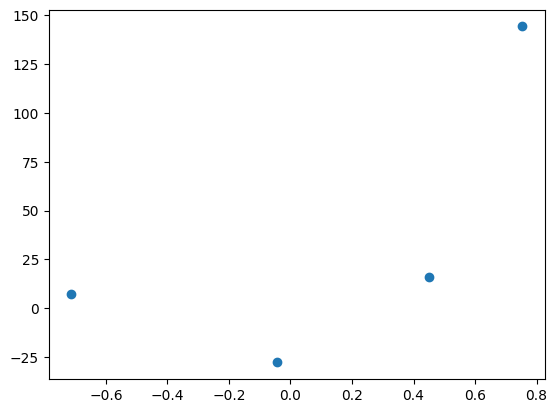

In [13]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [14]:
# lets apply ols 
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [15]:
reg.coef_

array([78.35063668])

In [16]:
reg.intercept_

np.float64(26.15963284313262)

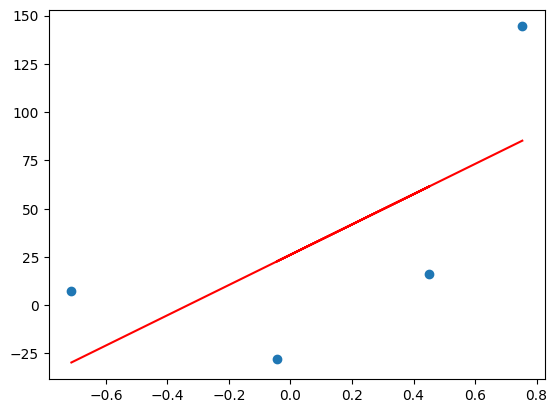

In [17]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red')

In [18]:
# lets apply gradient descent  assuming the slope is constant m=78.35
# and let  assume the starting value for the intercept is b=0
y_pred=((78.35*x)+0).reshape(4)


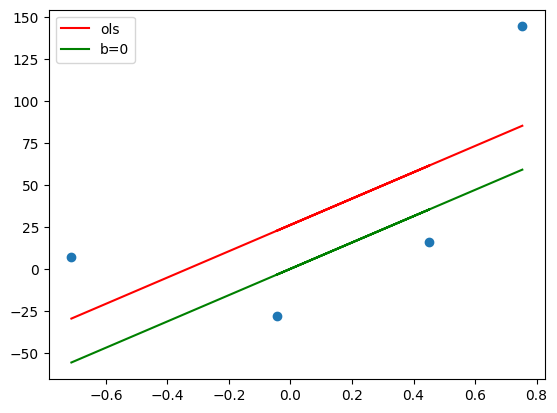

In [19]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='ols')
plt.plot(x,y_pred,color='green',label='b=0')
plt.legend()
plt.show()

In [20]:
m=78.35
b=0
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [21]:
# lets take learning rate as 0.1
lr=0.1
step_size=loss_slope*lr
step_size


np.float64(-20.927763408209216)

In [22]:
#calculating the new intercept
b=b-step_size
b

np.float64(20.927763408209216)

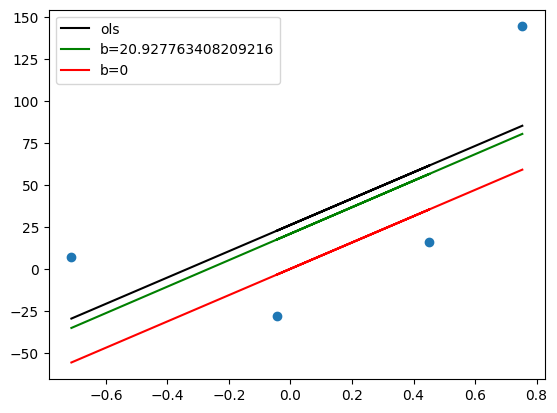

In [23]:
y_pred1=((78.85*x)+b).reshape(4)
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='black',label='ols')
plt.plot(x,y_pred1,color='green',label='b={}'.format(b))
plt.plot(x,y_pred,color='red',label='b=0')
plt.legend()
plt.show()

In [24]:
#iteration 2
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [25]:
step_size=loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [26]:
b=b-step_size
b

np.float64(25.11331608985106)

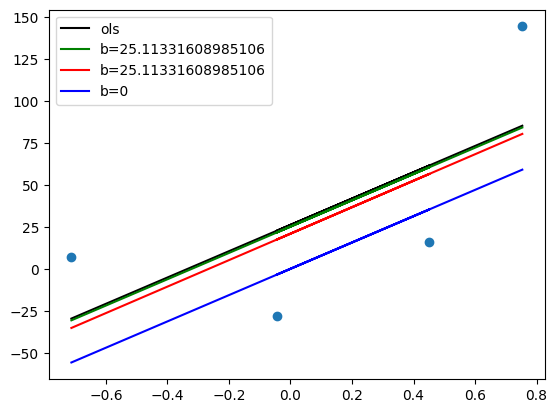

In [27]:
y_pred2=((78.35*x+b).reshape(4))
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='black',label='ols')
plt.plot(x,y_pred2,color='green',label='b={}'.format(b))
plt.plot(x,y_pred1,color='red',label='b={}'.format(b))
plt.plot(x,y_pred,color='blue',label='b=0')
plt.legend()
plt.show()

In [29]:
#iteration 3
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(-8.371105363283675)

In [30]:
step_size=loss_slope*lr
step_size

np.float64(-0.8371105363283675)

In [31]:
b=b-step_size
b

np.float64(25.95042662617943)

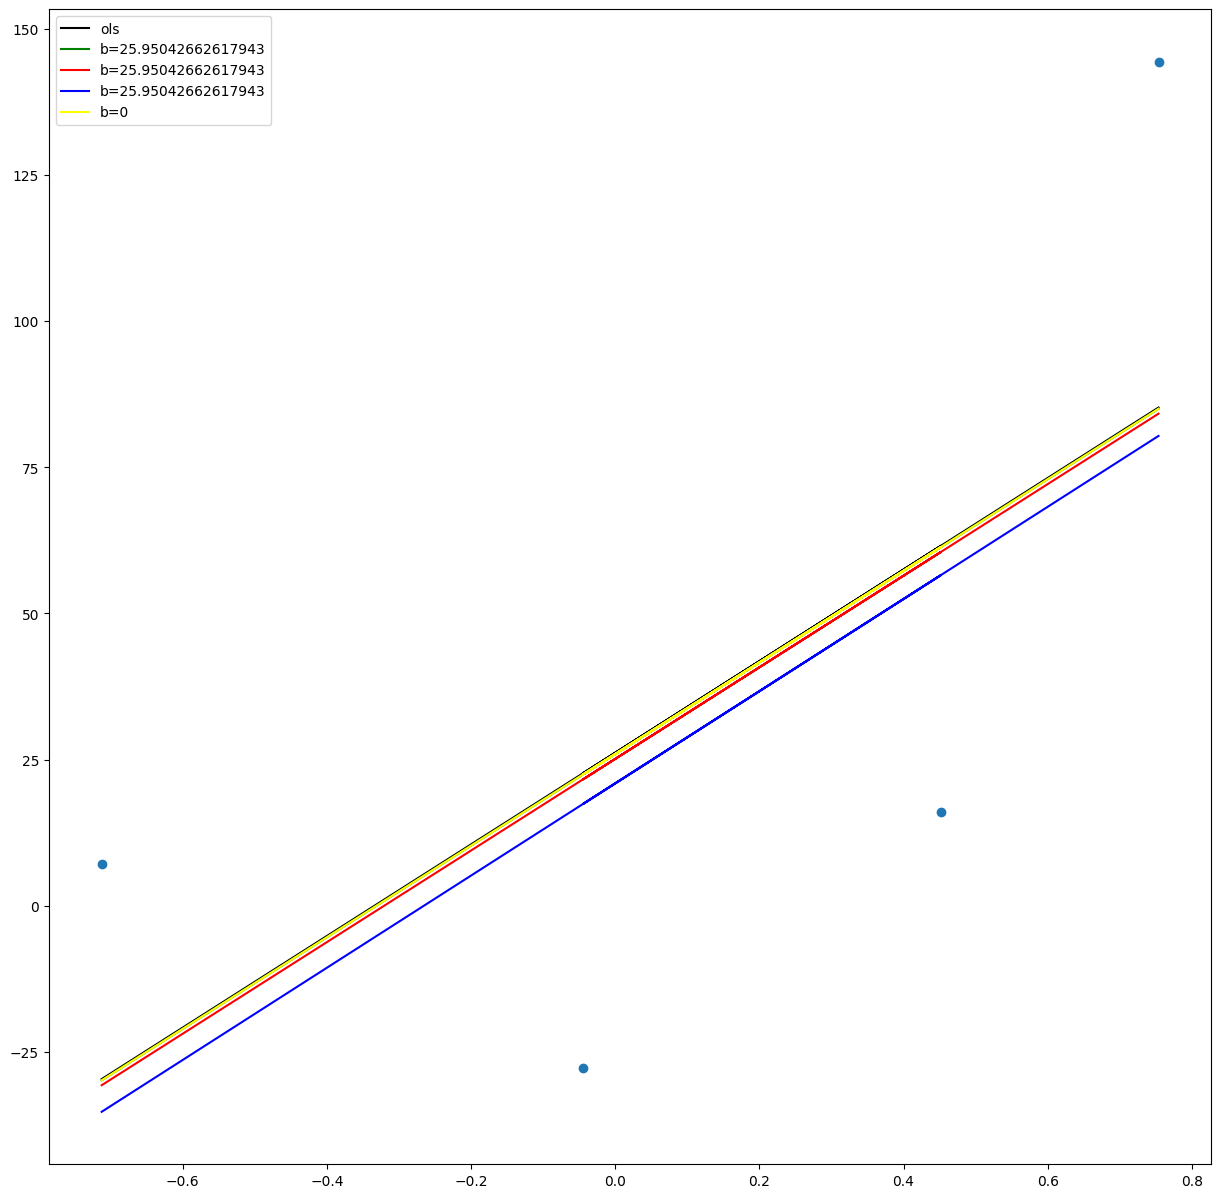

In [35]:
# see we are getting closerto the ols intercept value to 26.1 
y_pred3=((78.35*x)+b).reshape(4)
plt.figure(figsize=(15,15))
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='black',label='ols')
plt.plot(x,y_pred3,color='green',label='b={}' .format(b))
plt.plot(x,y_pred2,color='red',label='b={}'.format(b))
plt.plot(x,y_pred1,color='blue',label='b={}'.format(b))
plt.plot(x,y_pred,color='yellow',label='b=0')
plt.legend()
plt.show()

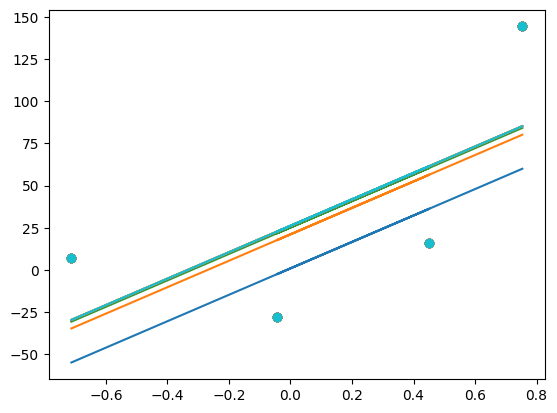

In [38]:
# getting all iteration together into a loop 
b=-100
m=78.35
lr=0.1
epochs=10
for i in range(epochs):
    loss_slope=-2*np.sum(y-m*x.ravel()-b)
    step_size=loss_slope*lr
    b=b-step_size

    y_pred=((78.35*x)+b).reshape(4)
    plt.plot(x,y_pred)
    plt.scatter(x,y)